In [25]:
%pip install seaborn
import seaborn as sns



In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import  LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
df = pd.read_csv("Diabetes_type2raw.csv")
df_clean=df.copy()
print(df_clean.head(10))
df_clean.drop(["Name"], axis=1,inplace=True,errors='ignore')

               Name  Gender  BP(Systolic)  BP(Diastolic) Physical_Activity  \
0     Michael Jones    Male         140.0           90.0               Low   
1      Sandra Green  Female         110.0           80.0               Low   
2    Jennifer Lewis  Female         120.0           80.0            Medium   
3   Ronald Gonzalez    Male         130.0           85.0               Low   
4   Ashley Mitchell  Female         110.0           75.0               Low   
5      Andrew Smith    Male         100.0           80.0              High   
6     Matthew Lewis    Male         110.0           80.0              High   
7      Melissa Hill  Female          90.0           65.0               Low   
8   Patricia Walker  Female         110.0           70.0              High   
9  Joseph Hernandez    Male         140.0           80.0               Low   

    Age        BMI  DiabetesPedigreeFunction  Insulin  Skin Thickness(mm)  \
0  50.0  22.263762                       0.0     92.3           

In [40]:
selected_cols = important_features.index.drop('Type 2 Diabetes')
X = df_clean[selected_cols]
y = df_clean['Type 2 Diabetes']
print(y.value_counts())
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
cols_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

Type 2 Diabetes
1    541
0    524
Name: count, dtype: int64


In [41]:
print("\n--- columns after Standardization:\n")
print(X_train[cols_to_scale].head())


--- columns after Standardization:

      Glucose       Age  BP(Systolic)  Skin Thickness(mm)
72  -0.918726  0.468171      1.463563            0.096208
904  0.295492  0.303921     -0.671879            1.290654
44  -1.210138 -1.174331      0.039935           -0.053098
309 -0.481607 -0.681580      0.751749            0.693431
789  0.732610 -0.353080     -1.383693           -0.053098


In [42]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
y_pred_lr = lr_model.predict(X_test)
print("Make Predictions:\n")
print(y_pred_lr)

Make Predictions:

[0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1 0 1 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 0 1 0
 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 1 0 1 1 0 1 0
 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 0 1 1 0 0
 0 1 1 0 1 0 1 0 0 0 1 1 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0
 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 0 0 1 0 1 1]


In [44]:
print("Logistic Regression Accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy
Accuracy: 0.971830985915493


In [45]:
print("\n--- Confusion Matrix ---\n")
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)


--- Confusion Matrix ---

[[101   1]
 [  5 106]]


In [46]:
print("\n--- Classification Report ---\n")
print(classification_report(y_test, y_pred_lr))


--- Classification Report ---

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       102
           1       0.99      0.95      0.97       111

    accuracy                           0.97       213
   macro avg       0.97      0.97      0.97       213
weighted avg       0.97      0.97      0.97       213




--- Confusion Matrix Visualization ---



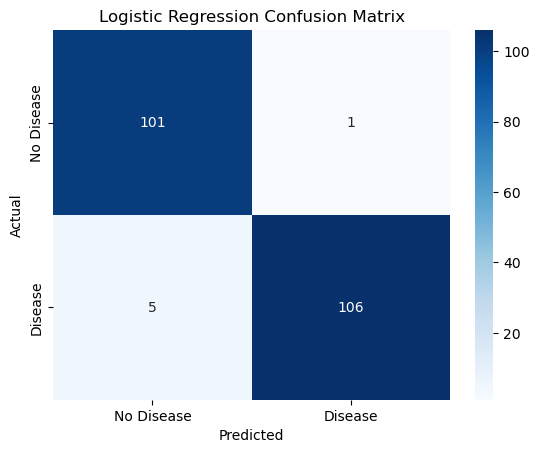

In [47]:
print("\n--- Confusion Matrix Visualization ---\n")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()